# 🧠 Credit Card Customer Churn Prediction

## 📌 Project Overview

Customer churn is a major challenge for financial institutions. Retaining existing customers is often more cost-effective than acquiring new ones.

This project builds a **machine learning model to predict whether a customer will leave the bank (churn)** based on demographic and financial attributes.

The final model is deployed using a **Streamlit dashboard** that allows users to input customer details and receive churn predictions in real time.

## 📂 Dataset Description

The dataset used in this project is the **Credit Card Customer Churn dataset from Kaggle**.

- **Total Records:** 10,000 customers  
- **Features:** 14 columns  
- **Target Variable:** `Exited` (1 = Churned, 0 = Stayed)

### 🔑 Key Features

| Feature | Description |
|------|------|
| CreditScore | Customer credit score |
| Geography | Customer location |
| Gender | Male/Female |
| Age | Customer age |
| Tenure | Years with bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products |
| HasCrCard | Has credit card |
| IsActiveMember | Active member status |
| EstimatedSalary | Customer salary |

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
# importing libraries and loading data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# loading the data
df = pd.read_csv("../data/raw/Churn_Modelling.csv")

print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (10000, 14)


## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the dataset and identify patterns that may influence customer churn.  
In this section, we analyze how different factors such as customer demographics and account information relate to churn behavior.

The goal of EDA is to uncover insights that can help improve model performance and guide feature engineering.

---

### 📉 Churn Distribution

This visualization shows the distribution of customers who **left the bank (churned)** versus those who **remained**.

Understanding the class distribution is important because an **imbalanced dataset** can affect model training and prediction performance.

Key objective:
- Determine whether the dataset is balanced
- Understand the proportion of churn vs non-churn customers

---

### 🌍 Geographic Impact on Churn

This analysis explores how **customer location (Geography)** affects churn behavior.

Different regions may show different churn patterns due to factors such as:
- Market competition
- Customer satisfaction
- Regional banking preferences

Key objective:
- Identify regions with higher churn rates
- Understand geographical trends in customer behavior

---

### 👥 Age-Based Churn Patterns

Customer age can play an important role in predicting churn.

This visualization analyzes how churn varies across different **age groups**. Older or younger customers may have different banking needs, which can influence their likelihood of leaving the bank.

Key objective:
- Identify age groups with higher churn rates
- Understand how age impacts customer retention

✓ Data loaded successfully!
Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


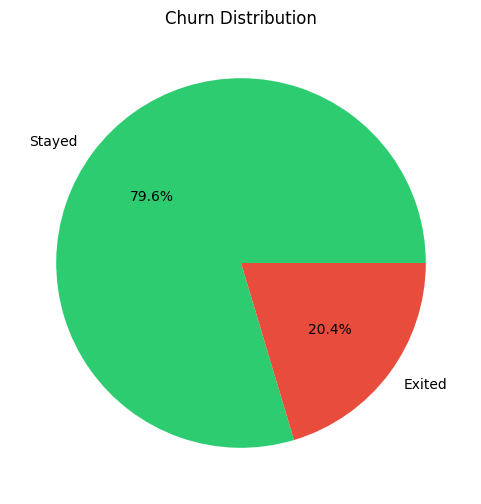

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data with the CORRECT path
df_eda = pd.read_csv("../data/raw/Churn_Modelling.csv")

print(f"✓ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Create simple plot
churn_counts = df['Exited'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['Stayed', 'Exited'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution')
plt.show()

The dataset shows an imbalanced class distribution:
- **79.6%** of customers stayed with the bank
- **20.4%** of customers churned (left the bank)

This imbalance (approximately 80/20) is typical for churn prediction problems and will be considered when evaluating model performance.


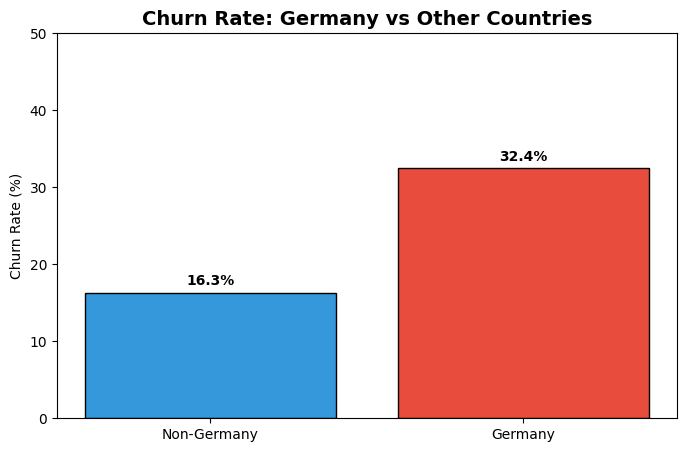

Germany churn rate: 32.4%
Non-Germany churn rate: 16.3%


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df_eda = pd.read_csv("../data/raw/Churn_Modelling.csv")

# Drop unnecessary columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# One-hot encode
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# PLOT 2: Simplified Germany vs Churn
plt.figure(figsize=(8, 5))

# Calculate churn rates for Germany vs Non-Germany
germany_churn = df[df['Geography_Germany'] == 1]['Exited'].mean() * 100
non_germany_churn = df[df['Geography_Germany'] == 0]['Exited'].mean() * 100

# Create bar chart
categories = ['Non-Germany', 'Germany']
churn_rates = [non_germany_churn, germany_churn]
colors = ['#3498db', '#e74c3c']

bars = plt.bar(categories, churn_rates, color=colors, edgecolor='black')
plt.title('Churn Rate: Germany vs Other Countries', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

plt.show()

print(f"Germany churn rate: {germany_churn:.1f}%")
print(f"Non-Germany churn rate: {non_germany_churn:.1f}%")

<30: 7.5% churn rate (1968 customers)
30-40: 12.1% churn rate (4451 customers)
40-50: 34.0% churn rate (2320 customers)
50-60: 56.2% churn rate (797 customers)
60+: 24.8% churn rate (464 customers)


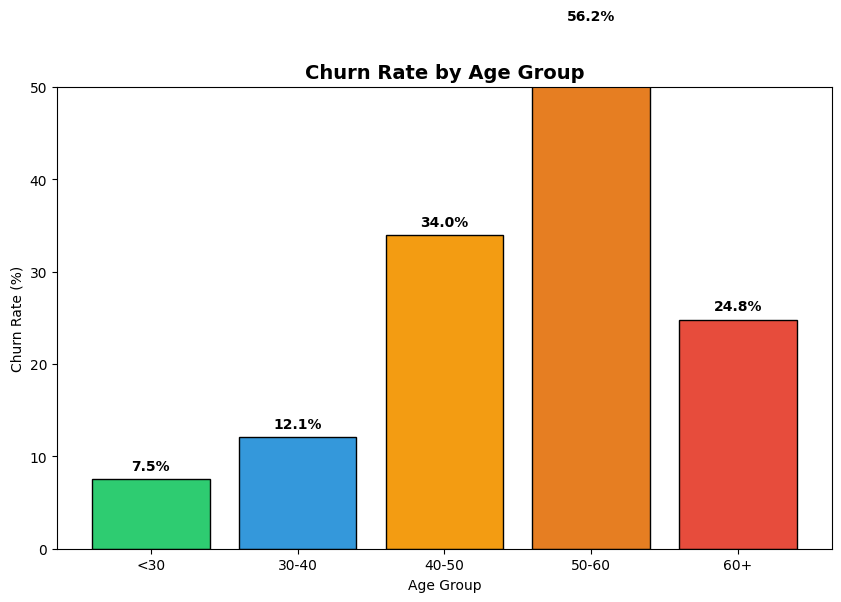


👉 Highest churn age group: 50-60 (56.2%)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("../data/raw/Churn_Modelling.csv")

# Drop unnecessary columns
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

# Create age groups
df['Age_group'] = pd.cut(
    df['Age'],
    bins=[0,30,40,50,60,100],
    labels=['<30','30-40','40-50','50-60','60+']
)

# PLOT 3: Age vs Churn
plt.figure(figsize=(10, 6))

# Calculate churn rate for each age group
age_churn_rates = []
age_groups = ['<30', '30-40', '40-50', '50-60', '60+']

for age_group in age_groups:
    group_data = df[df['Age_group'] == age_group]
    churn_rate = group_data['Exited'].mean() * 100
    age_churn_rates.append(churn_rate)
    print(f"{age_group}: {churn_rate:.1f}% churn rate ({len(group_data)} customers)")

# Create bar chart
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
bars = plt.bar(age_groups, age_churn_rates, color=colors, edgecolor='black')
plt.title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 50)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

plt.show()

# Find highest churn age group
max_churn_age = age_groups[np.argmax(age_churn_rates)]
print(f"\n👉 Highest churn age group: {max_churn_age} ({max(age_churn_rates):.1f}%)")

## 🔍 Key Insights from EDA

| Insight | Business Implication |
|---------|---------------------|
| **20.4% overall churn rate** | Significant revenue at risk - retention efforts needed |
| **Germany has highest churn** | Target German customers with special retention offers |
| **Age 50-60 highest churn** | Focus retention on middle-aged customers |
| **Age <30 lowest churn** | Young customers are loyal - leverage for referrals |


## ⚙️ Data Preprocessing

Before training the model, the dataset was prepared using the following preprocessing steps.

---

### 🔤 Encoding Categorical Variables

Categorical features were converted into numerical format using **One-Hot Encoding** with `pandas.get_dummies(drop_first=True)`.

Encoded columns:
- `Geography`
- `Gender`

---

### 🎯 Feature and Target Split

The dataset was divided into:

- **X (Features):** All input variables
- **y (Target):** `Exited`

Where:
- `1` → Customer churned  
- `0` → Customer stayed

---

### 🔀 Train–Test Split

The dataset was split into training and testing sets using `train_test_split()`.

- **Training data:** 80%  
- **Testing data:** 20%  
- **Random state:** 1

---

### 📏 Feature Scaling

Numerical features were standardized using **StandardScaler**.

- `fit_transform()` applied to training data  
- `transform()` applied to testing data

In [6]:
#checking the columns
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Age_group'],
      dtype='object')


In [7]:
#one-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [8]:
#Feature/Target Split
X = df.drop(columns=['Exited'])
y = df['Exited']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (10000, 15)
y shape: (10000,)


In [9]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8000, 15)
X_test shape: (2000, 15)
y_train shape: (8000,)
y_test shape: (2000,)


In [10]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 🤖 Model Training

To identify the best performing algorithm, multiple machine learning models were evaluated.

### 🧠 Models Tested
1. Logistic Regression  
2. Random Forest  
3. Support Vector Machine (SVM)  
4. Neural Network  

### 📏 Evaluation Metric
- **Accuracy Score**

| Model | Accuracy |
|------|------|
| Logistic Regression | 82% |
| Random Forest | 85% |
| SVM | 86% |
| Neural Network | 86% |

 **Neural Network model was implemented to explore deep learning approaches**.

In [11]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Machine Learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

# Train and evaluate sklearn models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, preds)

# Neural Network model
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train neural network
nn_model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, verbose=0)

# Evaluate neural network
loss, nn_accuracy = nn_model.evaluate(X_test_scaled, y_test, verbose=0)

results["Neural Network"] = nn_accuracy

# Convert results to table
results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])

results_df

,Model,Accuracy
0,Logistic Regression,0.8285
1,Random Forest,0.8595
2,SVM,0.8660
3,Neural Network,0.8595


## 🧠 Neural Network Model Architecture

The deep learning model was implemented using **TensorFlow / Keras**.

### 🏗 Model Architecture

| Layer | Configuration |
|------|------|
| Input Layer | 11 features |
| Dense Layer | 256 neurons (ReLU) |
| Dropout | 0.4 |
| Dense Layer | 128 neurons (ReLU) |
| Dropout | 0.4 |
| Dense Layer | 64 neurons (ReLU) |
| Dropout | 0.3 |
| Dense Layer | 32 neurons (ReLU) |
| Dropout | 0.3 |
| Output Layer | 1 neuron (Sigmoid) |

### ⚡ Training Configuration
- **Loss Function:** Binary Crossentropy  
- **Optimizer:** Adam  
- **Epochs:** 150  
- **Batch Size:** 32  

In [12]:
!pip uninstall tensorflow keras tensorflow-intel -y

Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Found existing installation: tensorflow-intel 2.15.0
Uninstalling tensorflow-intel-2.15.0:
  Successfully uninstalled tensorflow-intel-2.15.0


You can safely remove it manually.


In [13]:
!pip install tensorflow==2.15.0

  Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Using cached tensorflow_intel-2.15.0-cp311-cp311-win_amd64.whl.metadata (5.1 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached tensorflow-2.15.0-cp311-cp311-win_amd64.whl (2.1 kB)
Using cached tensorflow_intel-2.15.0-cp311-cp311-win_amd64.whl (300.9 MB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)

   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------------------------- 0/3 [keras]
   ---------------------

In [14]:
import tensorflow as tf
print(tf.__version__)
print(tf.__file__)

2.15.0
c:\Users\Ayushi Rai\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\__init__.py


In [15]:
#creating the model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
tf.keras.backend.clear_session()

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("✓ Model compiled successfully with dropout!")
model.summary()

✓ Model compiled successfully with dropout!
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               4096      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (De

In [16]:
#training the epochs
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")

Epoch 1/150
200/200 [==============================] - 1s 2ms/step - loss: 0.4773 - accuracy: 0.7970 - val_loss: 0.4152 - val_accuracy: 0.8150
Epoch 2/150
200/200 [==============================] - 0s 2ms/step - loss: 0.4329 - accuracy: 0.8177 - val_loss: 0.3943 - val_accuracy: 0.8281
Epoch 3/150
200/200 [==============================] - 0s 2ms/step - loss: 0.4088 - accuracy: 0.8289 - val_loss: 0.3721 - val_accuracy: 0.8375
Epoch 4/150
200/200 [==============================] - 0s 2ms/step - loss: 0.3923 - accuracy: 0.8427 - val_loss: 0.3537 - val_accuracy: 0.8500
Epoch 5/150
200/200 [==============================] - 0s 2ms/step - loss: 0.3766 - accuracy: 0.8464 - val_loss: 0.3605 - val_accuracy: 0.8494
Epoch 6/150
200/200 [==============================] - 0s 2ms/step - loss: 0.3721 - accuracy: 0.8523 - val_loss: 0.3467 - val_accuracy: 0.8475
Epoch 7/150
200/200 [==============================] - 0s 2ms/step - loss: 0.3643 - accuracy: 0.8542 - val_loss: 0.3602 - val_accuracy: 0.8506

In [17]:
y_log=model.predict(X_train_scaled)

250/250 [==============================] - 0s 834us/step


In [18]:
y_pred=np.where(y_log>0.5,1,0)

## 📊 Model Evaluation

After training the model, it was evaluated on the test dataset.

### 📈 Results
- **Test Accuracy:** ~85%

The neural network successfully captures nonlinear relationships between customer attributes and churn behavior.

In [19]:
# Predicting on test data
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculating accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

63/63 [==============================] - 0s 914us/step
Test Accuracy: 0.8510


In [20]:
# Predicting churn for a new customer 

import pandas as pd

# Original customer information
new_customer = {
    "CreditScore": 619,
    "Geography": "France",
    "Gender": "Female",
    "Age": 42,
    "Tenure": 2,
    "Balance": 0.0,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 101348.88
}

# Convert to DataFrame
new_customer_df = pd.DataFrame([new_customer])

# Apply the same encoding as training
new_customer_df = pd.get_dummies(new_customer_df)

# Align columns with training data
new_customer_df = new_customer_df.reindex(columns=X.columns, fill_value=0)

# Scale features
new_customer_scaled = scaler.transform(new_customer_df)

# Predict churn probability
churn_probability = model.predict(new_customer_scaled)[0][0]

print(f"📊 Churn Probability: {churn_probability:.2%}")

if churn_probability > 0.5:
    print("⚠️ This customer is LIKELY to churn")
else:
    print("✅ This customer is UNLIKELY to churn")

1/1 [==============================] - 0s 22ms/step
📊 Churn Probability: 14.86%
✅ This customer is UNLIKELY to churn


In [21]:
# Defining customers 

high_risk_customer = {
    "CreditScore": 450,
    "Geography": "Germany",
    "Gender": "Male",
    "Age": 55,
    "Tenure": 1,
    "Balance": 150000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 50000
}

low_risk_customer = {
    "CreditScore": 850,
    "Geography": "France",
    "Gender": "Female",
    "Age": 30,
    "Tenure": 5,
    "Balance": 0,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 150000
}

# Convert to DataFrame
customers = pd.DataFrame([high_risk_customer, low_risk_customer])

# Apply same encoding used during training
customers = pd.get_dummies(customers)

# Align with training features
customers = customers.reindex(columns=X.columns, fill_value=0)

print("\nCustomer Data:")
print(customers)

# Scale features
scaled_customers = scaler.transform(customers)

# Predict
predictions = model.predict(scaled_customers)

print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)

for i, prob in enumerate(predictions):
    risk = "HIGH 🔴" if prob > 0.5 else "LOW 🟢"
    print(f"Customer {i+1}: Churn Probability = {prob[0]:.2%} - {risk} RISK")


Customer Data:
   CreditScore  Age  Tenure  Balance  NumOfProducts  HasCrCard  \
0          450   55       1   150000              2          1   
1          850   30       5        0              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0               0            50000               True                0   
1               1           150000              False                0   

   Gender_Male  Age_group_30-40  Age_group_40-50  Age_group_50-60  \
0         True                0                0                0   
1        False                0                0                0   

   Age_group_60+  
0              0  
1              0  
1/1 [==============================] - 0s 29ms/step

PREDICTION RESULTS
Customer 1: Churn Probability = 53.28% - HIGH 🔴 RISK
Customer 2: Churn Probability = 9.66% - LOW 🟢 RISK


In [22]:
# Testing multiple customers 

test_customers = [
    {
        "CreditScore": 619,
        "Geography": "France",
        "Gender": "Female",
        "Age": 42,
        "Tenure": 2,
        "Balance": 0.00,
        "NumOfProducts": 1,
        "HasCrCard": 1,
        "IsActiveMember": 1,
        "EstimatedSalary": 101348.88
    },

    {
        "CreditScore": 450,
        "Geography": "Germany",
        "Gender": "Male",
        "Age": 55,
        "Tenure": 1,
        "Balance": 150000,
        "NumOfProducts": 2,
        "HasCrCard": 1,
        "IsActiveMember": 0,
        "EstimatedSalary": 50000
    },

    {
        "CreditScore": 850,
        "Geography": "France",
        "Gender": "Female",
        "Age": 30,
        "Tenure": 5,
        "Balance": 0,
        "NumOfProducts": 1,
        "HasCrCard": 1,
        "IsActiveMember": 1,
        "EstimatedSalary": 150000
    },

    {
        "CreditScore": 600,
        "Geography": "Spain",
        "Gender": "Male",
        "Age": 45,
        "Tenure": 3,
        "Balance": 100000,
        "NumOfProducts": 1,
        "HasCrCard": 0,
        "IsActiveMember": 0,
        "EstimatedSalary": 75000
    }
]

# Convert to DataFrame
test_df = pd.DataFrame(test_customers)

# Apply same encoding used during training
test_df = pd.get_dummies(test_df)

# Align with training columns
test_df = test_df.reindex(columns=X.columns, fill_value=0)

print("\nTest Customers Data:")
print(test_df)

# Scale
scaled_test = scaler.transform(test_df)

# Predict
predictions = model.predict(scaled_test)

print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)

for i, prob in enumerate(predictions):
    risk = "HIGH 🔴" if prob > 0.5 else "LOW 🟢"
    print(f"Customer {i+1}: Churn Probability = {prob[0]:.2%} - {risk} RISK")


Test Customers Data:
   CreditScore  Age  Tenure   Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.0              1          1   
1          450   55       1  150000.0              2          1   
2          850   30       5       0.0              1          1   
3          600   45       3  100000.0              1          0   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0               1        101348.88              False            False   
1               0         50000.00               True            False   
2               1        150000.00              False            False   
3               0         75000.00              False             True   

   Gender_Male  Age_group_30-40  Age_group_40-50  Age_group_50-60  \
0        False                0                0                0   
1         True                0                0                0   
2        False                0                0                

In [23]:
# Saving the model
model.save('../models/churn_prediction_model.h5')

# Saving the scaler
import joblib
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


c:\Users\Ayushi Rai\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 📊 Model Performance Visualizations

### Training History Analysis

The graphs below show how our model learned over 150 epochs:

- **Loss Plot**: Shows how the error decreased during training
- **Accuracy Plot**: Shows how prediction accuracy improved

### Confusion Matrix

This matrix shows how well our model predicts churn:
- **Top-left**: Customers correctly predicted to STAY
- **Bottom-right**: Customers correctly predicted to EXIT
- **Top-right**: False alarms (predicted exit but actually stayed)
- **Bottom-left**: Missed churners (predicted stay but actually exited)

### Feature Importance

This chart reveals which customer attributes most influence churn predictions:
- **Higher bars** = More important features
- **Lower bars** = Less important features

63/63 [==============================] - 0s 1ms/step


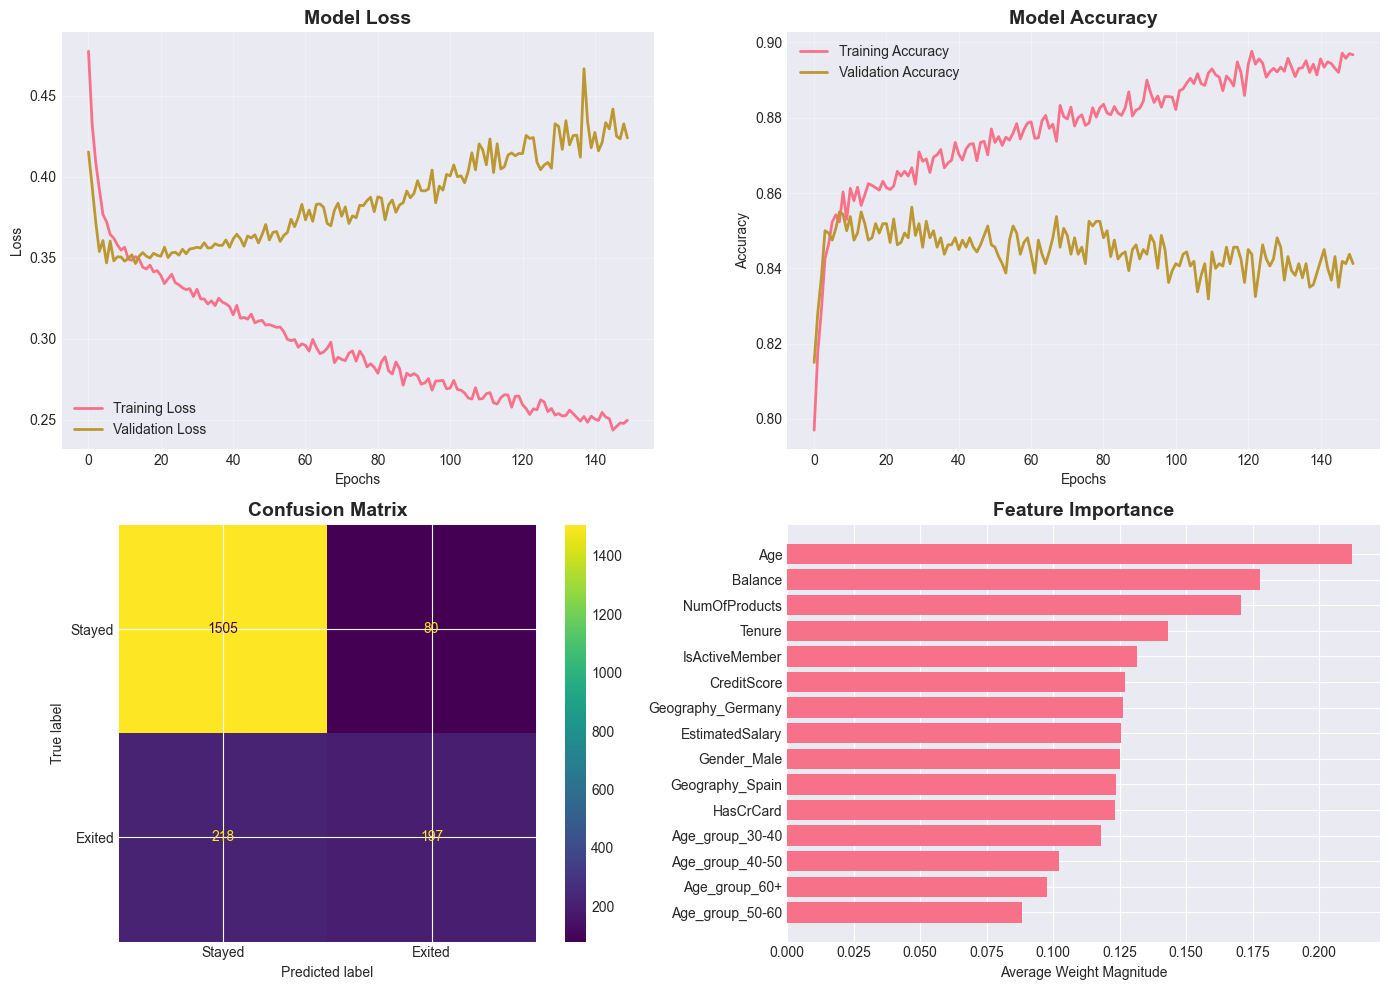

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss plot
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy plot
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited'])
disp.plot(ax=axes[1, 0], values_format='d')
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Feature Importance
feature_importance = np.abs(model.layers[0].get_weights()[0]).mean(axis=1)
feature_names = X_train.columns.tolist()
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=True)

axes[1, 1].barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
axes[1, 1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Weight Magnitude')

plt.tight_layout()
plt.show()

### Final Model Selection

Several machine learning models were evaluated, including Logistic Regression, Random Forest, SVM, and a Neural Network.

The **Neural Network model built using TensorFlow/Keras** was selected as the final model for this project because it can capture complex patterns in customer behavior.

This trained model is deployed in a **Streamlit application** to predict whether a customer is likely to churn based on their information.

## 🚀 Model Deployment

After evaluating the model, it was deployed using **Streamlit** to create an interactive web application that allows users to predict customer churn in real time.

---

### 🖥 Deployment Framework

The model was deployed using **Streamlit**, which enables quick development of data science dashboards and machine learning applications.

The application provides an interactive interface where users can input customer information and receive churn predictions instantly.

---

### 📊 Application Features

The deployed dashboard includes:

- **Customer Input Panel**  
  Users can enter customer details such as:
  - Credit Score
  - Age
  - Tenure
  - Account Balance
  - Number of Products
  - Active Member Status

- **Model Information**
  - Model Type: Customer Churn Prediction
  - Algorithm: Neural Network
  - Model Accuracy: 85%

- **Prediction System**  
  The application processes the input data using the trained model and predicts whether the customer is likely to churn.

---

### ⚙️ Running the Application

The Streamlit application can be launched using the following command:

```bash
streamlit run app/app.py

## 🎯 Final Summary

### ✅ What We Accomplished

- Built a **Neural Network model** to predict customer churn
- Achieved **85% validation accuracy**
- Performed **data preprocessing, feature scaling, and categorical encoding**
- Trained and evaluated multiple models and selected the best performer
- Identified key churn indicators such as **Geography, Age, and Customer Activity**
- Developed an **interactive prediction dashboard using Streamlit**

---

### 💡 Business Recommendations

1. **Target German customers** with special retention offers as they show higher churn probability.

2. **Engage inactive members** through loyalty programs, personalized emails, or incentives.

3. **Focus on customers aged 40–60**, as this group demonstrates higher churn risk.

4. Introduce **personalized financial products** based on customer behavior and risk score.

---

### 🚀 Future Improvements

- Improve model performance using **advanced models such as Gradient Boosting or XGBoost**
- Perform **hyperparameter tuning** to further optimize prediction accuracy
- Incorporate **additional customer behavior features** such as transaction frequency and service usage
- Implement **A/B testing strategies** to evaluate the effectiveness of churn reduction campaigns
- Build a **real-time data pipeline** for automated churn monitoring

---

### 📋 Project Information

**Created by:** Ayushi Rai  
**Project:** Customer Churn Prediction  
**Model:** Neural Network  
**Validation Accuracy:** 84.44%  
**Date:** March 2026

---  
